<a href="https://colab.research.google.com/github/Nikhil4002-50-82/Automatic-Pedicle-Screw-Planning/blob/main/spine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Phase1***

In [ ]:
!pip -q install nibabel SimpleITK scipy scikit-image tqdm vtk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 MB 9.4 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

print("Uploaded files:", list(uploaded.keys()))

Saving spine_2-label.nii to spine_2-label.nii
Saving case_0000.nii to case_0000.nii
Uploaded files: ['spine_2-label.nii', 'case_0000.nii']


In [ ]:
import nibabel as nib
import numpy as np
import json
from scipy.ndimage import distance_transform_edt

def normalize(v):
    v = np.asarray(v, dtype=np.float64)
    n = np.linalg.norm(v)
    return v / n if n > 1e-8 else v * 0.0

def rotate_axis_angle(v, axis, angle):
    axis = normalize(axis)
    c, s = np.cos(angle), np.sin(angle)
    return v * c + np.cross(axis, v) * s + axis * (np.dot(axis, v)) * (1 - c)

def ijk_to_world_ras(ijk, affine):
    p = np.array([ijk[0], ijk[1], ijk[2], 1.0])
    return (affine @ p)[:3]

def world_to_ijk_ras(xyz, affine):
    inv_affine = np.linalg.inv(affine)
    p = np.array([xyz[0], xyz[1], xyz[2], 1.0])
    return (inv_affine @ p)[:3]

def zyx_to_ijk(zyx): return np.array([zyx[2], zyx[1], zyx[0]])
def ijk_to_zyx(ijk): return np.array([ijk[2], ijk[1], ijk[0]])

def compute_vertebra_coordinate_system(mask, affine):
    zyx = np.argwhere(mask)
    pts_ijk = np.stack([zyx[:, 2], zyx[:, 1], zyx[:, 0]], axis=1).astype(np.float64)
    pts_world = np.array([ijk_to_world_ras(p, affine) for p in pts_ijk[::10]])

    origin = np.mean(pts_world, axis=0)
    X = pts_world - origin
    _, _, Vt = np.linalg.svd(X, full_matrices=False)

    a0, a1, a2 = Vt[0], Vt[1], Vt[2]
    cc_idx = np.argmax([abs(np.dot(a, [0,0,1])) for a in [a0,a1,a2]])
    CC = Vt[cc_idx]
    if np.dot(CC, [0,0,1]) < 0: CC = -CC

    rem = [i for i in [0,1,2] if i != cc_idx]
    b0, b1 = Vt[rem[0]], Vt[rem[1]]

    if abs(np.dot(b0, [1,0,0])) > abs(np.dot(b1, [1,0,0])):
        LR, AP = b0, b1
    else:
        LR, AP = b1, b0

    if np.dot(LR, [1,0,0]) < 0: LR = -LR
    if np.dot(AP, [0,1,0]) < 0: AP = -AP

    return origin, {"LR": normalize(LR), "AP": normalize(AP), "CC": normalize(CC)}

def estimate_entry_point(side_mask, affine, origin_world, axes, side="Left"):
    zyx = np.argwhere(side_mask)
    if len(zyx) < 100: return None
    pts_ijk = np.stack([zyx[:, 2], zyx[:, 1], zyx[:, 0]], axis=1).astype(np.float64)
    pts_world = np.array([ijk_to_world_ras(p, affine) for p in pts_ijk])

    ap_proj = (pts_world - origin_world) @ axes["AP"]
    thr = np.percentile(ap_proj, 25)
    post_pts = pts_world[ap_proj <= thr]

    cc_proj = (post_pts - origin_world) @ axes["CC"]
    cc_mid = np.median(cc_proj)
    band_pts = post_pts[np.abs(cc_proj - cc_mid) <= 4.0]

    if len(band_pts) == 0: return None

    lr_proj = (band_pts - origin_world) @ axes["LR"]
    target_pct = 65 if side == "Left" else 35
    target = np.percentile(lr_proj, target_pct)

    best_pt = band_pts[np.argmin(np.abs(lr_proj - target))]
    return world_to_ijk_ras(best_pt, affine)

def optimize_pedicle(ct, mask, dt, entry_ijk, axes, affine, spacing, side="Left"):
    medial_vec = (-axes["LR"]) if side == "Left" else axes["LR"]
    base_dir = normalize(axes["AP"] + 0.35 * medial_vec)

    best = None
    best_score = -1e9

    for yaw in [-20, -15, -10, -5, 0, 5, 10, 15, 20]:
        for pitch in [-15, -10, -5, 0, 5, 10, 15]:
            d = rotate_axis_angle(base_dir, axes["CC"], np.deg2rad(yaw))
            d = rotate_axis_angle(d, axes["LR"], np.deg2rad(pitch))

            p0_world = ijk_to_world_ras(entry_ijk, affine)
            clearance_vals = []
            hu_vals = []

            for dist in np.arange(0, 80, 1.5):
                p_world = p0_world + d * dist
                p_ijk = world_to_ijk_ras(p_world, affine)
                z,y,x = np.round(ijk_to_zyx(p_ijk)).astype(int)

                if z<0 or y<0 or x<0 or z>=mask.shape[0] or y>=mask.shape[1] or x>=mask.shape[2]:
                    break
                if not mask[z,y,x]:
                    break

                clearance_vals.append(dt[z,y,x] * spacing)
                hu_vals.append(ct[z,y,x])

            if len(clearance_vals) < 12: continue

            min_c = np.min(clearance_vals)
            if min_c < 0.3: continue

            p20_c = np.percentile(clearance_vals, 20)
            avg_hu = np.mean(hu_vals)
            length = len(clearance_vals) * 1.5

            score = (5.0 * p20_c) + (2.0 * min_c) + (0.002 * avg_hu) + (0.1 * length)

            if score > best_score:
                best_score = score
                best = {
                    "axis_world": d,
                    "length_mm": float(np.clip(length-2, 20, 60)),
                    "diam_mm": float(np.clip(p20_c*2, 3.5, 7.5)),
                    "min_clear_mm": float(min_c),
                    "mean_hu": float(avg_hu),
                    "score": float(score)
                }
    return best

In [ ]:
import vtk
from vtk.util.numpy_support import numpy_to_vtk

def save_screw_line_vtp(path, entry_world, stop_world, name="screw"):
    points = vtk.vtkPoints()
    points.SetNumberOfPoints(2)
    points.SetPoint(0, float(entry_world[0]), float(entry_world[1]), float(entry_world[2]))
    points.SetPoint(1, float(stop_world[0]),  float(stop_world[1]),  float(stop_world[2]))

    line = vtk.vtkLine()
    line.GetPointIds().SetId(0, 0)
    line.GetPointIds().SetId(1, 1)

    lines = vtk.vtkCellArray()
    lines.InsertNextCell(line)

    poly = vtk.vtkPolyData()
    poly.SetPoints(points)
    poly.SetLines(lines)

    name_arr = vtk.vtkStringArray()
    name_arr.SetName("name")
    name_arr.InsertNextValue(name)
    poly.GetFieldData().AddArray(name_arr)

    writer = vtk.vtkXMLPolyDataWriter()
    writer.SetFileName(path)
    writer.SetInputData(poly)
    writer.Write()

ct_path = "case_0000.nii"
seg_path = "spine_2-label.nii"
vertebra_names = {1:"L1", 2:"L2", 3:"L3", 4:"L4", 5:"L5"}

ct_nii = nib.load(ct_path)
seg_nii = nib.load(seg_path)

ct = ct_nii.get_fdata().astype(np.float32)
seg = seg_nii.get_fdata().astype(np.int16)

affine = seg_nii.affine

spacing_xyz = np.linalg.norm(affine[:3, :3], axis=0)
spacing_mm = float(np.mean(spacing_xyz))

print("CT shape:", ct.shape)
print("SEG shape:", seg.shape)
print("Spacing xyz (mm):", spacing_xyz)

results = {}

fcsv_rows = [
    "# Markups fiducial file version = 4.11",
    "# CoordinateSystem = RAS",
    "# columns = id,x,y,z,ow,ox,oy,oz,vis,sel,lock,label,desc,associatedNodeID"
]
fcsv_idx = 1

for lab, vname in vertebra_names.items():
    print("\n======================")
    print(f"Planning: {vname}")

    vmask = (seg == lab)
    if vmask.sum() < 800:
        print("  Skipped: too few voxels")
        continue

    dt = distance_transform_edt(vmask)

    origin, axes = compute_vertebra_coordinate_system(vmask, affine)

    vertebra_plan = {}

    for side in ["Left", "Right"]:
        entry_ijk = estimate_entry_point(vmask, affine, origin, axes, side=side)
        if entry_ijk is None:
            print(f"  {side}: entry not found")
            continue

        best_plan = optimize_pedicle(
            ct=ct,
            mask=vmask,
            dt=dt,
            entry_ijk=entry_ijk,
            axes=axes,
            affine=affine,
            spacing=spacing_mm,
            side=side
        )

        if not best_plan:
            print(f"  {side}: No valid trajectory found.")
            continue

        entry_world = ijk_to_world_ras(entry_ijk, affine)
        stop_world = entry_world + np.array(best_plan["axis_world"]) * float(best_plan["length_mm"])

        for pt_name, coords in [("ENTRY", entry_world), ("STOP", stop_world)]:
            fcsv_rows.append(
                f"vtkMRMLMarkupsFiducialNode_{fcsv_idx},"
                f"{coords[0]},{coords[1]},{coords[2]},"
                "0,0,0,1,1,1,0,"
                f"{vname}_{side}_{pt_name},,"
            )
            fcsv_idx += 1

        vtp_name = f"{vname}_{side}_screw.vtp"
        save_screw_line_vtp(
            vtp_name,
            entry_world=entry_world,
            stop_world=stop_world,
            name=f"{vname}_{side}"
        )

        vertebra_plan[side] = {
            "entry_world_ras": entry_world.tolist(),
            "stop_world_ras": stop_world.tolist(),
            "axis_world_ras": np.array(best_plan["axis_world"]).tolist(),
            "length_mm": float(best_plan["length_mm"]),
            "diam_mm": float(best_plan["diam_mm"]),
            "min_clear_mm": float(best_plan["min_clear_mm"]),
            "mean_hu": float(best_plan["mean_hu"]),
            "score": float(best_plan["score"])
        }

        print(f"  {side}: Success! L={best_plan['length_mm']:.1f} D={best_plan['diam_mm']:.1f}")

    results[vname] = vertebra_plan

with open("phase1_plan.json", "w") as f:
    json.dump(results, f, indent=2)

with open("phase1_visualization.fcsv", "w") as f:
    f.write("\n".join(fcsv_rows))

print("\nDONE!")
print("Saved:")
print("  phase1_plan.json")
print("  phase1_visualization.fcsv")
print("  plus per-screw .vtp line models like L3_Left_screw.vtp")

CT shape: (366, 424, 283)
SEG shape: (366, 424, 283)
Spacing xyz (mm): [1.49999998 1.49999998 1.5       ]

Planning: L1
  Left: No valid trajectory found.
  Right: Success! L=26.5 D=4.2

Planning: L2
  Left: No valid trajectory found.
  Right: Success! L=20.0 D=7.1

Planning: L3
  Left: No valid trajectory found.
  Right: Success! L=20.0 D=3.7

Planning: L4
  Left: No valid trajectory found.
  Right: No valid trajectory found.

Planning: L5
  Left: No valid trajectory found.
  Right: Success! L=20.0 D=3.5

DONE!
Saved:
  phase1_plan.json
  phase1_visualization.fcsv
  plus per-screw .vtp line models like L3_Left_screw.vtp


# ***Phase2***

In [ ]:
from tqdm import tqdm
from scipy.ndimage import binary_dilation, binary_erosion

def normalize(v):
    v = np.asarray(v, dtype=np.float64)
    n = np.linalg.norm(v)
    return v / n if n > 1e-8 else v * 0.0

def rotate_axis_angle(v, axis, angle):
    axis = normalize(axis)
    c, s = np.cos(angle), np.sin(angle)
    return v * c + np.cross(axis, v) * s + axis * (np.dot(axis, v)) * (1 - c)

def ijk_to_world_ras(ijk, affine):
    p = np.array([ijk[0], ijk[1], ijk[2], 1.0])
    return (affine @ p)[:3]

def world_to_ijk_ras(xyz, affine):
    inv_affine = np.linalg.inv(affine)
    p = np.array([xyz[0], xyz[1], xyz[2], 1.0])
    return (inv_affine @ p)[:3]

def ijk_to_zyx(ijk):
    return np.array([ijk[2], ijk[1], ijk[0]], dtype=np.float64)

def zyx_to_ijk(zyx):
    return np.array([zyx[2], zyx[1], zyx[0]], dtype=np.float64)

def save_screw_line_vtp(path, entry_world, stop_world, name="screw"):
    points = vtk.vtkPoints()
    points.SetNumberOfPoints(2)
    points.SetPoint(0, float(entry_world[0]), float(entry_world[1]), float(entry_world[2]))
    points.SetPoint(1, float(stop_world[0]),  float(stop_world[1]),  float(stop_world[2]))

    line = vtk.vtkLine()
    line.GetPointIds().SetId(0, 0)
    line.GetPointIds().SetId(1, 1)

    lines = vtk.vtkCellArray()
    lines.InsertNextCell(line)

    poly = vtk.vtkPolyData()
    poly.SetPoints(points)
    poly.SetLines(lines)

    name_arr = vtk.vtkStringArray()
    name_arr.SetName("name")
    name_arr.InsertNextValue(name)
    poly.GetFieldData().AddArray(name_arr)

    writer = vtk.vtkXMLPolyDataWriter()
    writer.SetFileName(path)
    writer.SetInputData(poly)
    writer.Write()

def compute_axes_body_only(vmask, affine, subsample=8):
    zyx = np.argwhere(vmask)
    pts_ijk = np.stack([zyx[:, 2], zyx[:, 1], zyx[:, 0]], axis=1).astype(np.float64)
    pts_world = np.array([ijk_to_world_ras(p, affine) for p in pts_ijk[::subsample]])

    origin1 = np.mean(pts_world, axis=0)
    X1 = pts_world - origin1
    _, _, Vt1 = np.linalg.svd(X1, full_matrices=False)

    cc_idx = np.argmax([abs(np.dot(a, [0,0,1])) for a in Vt1])
    CC = Vt1[cc_idx]
    if np.dot(CC, [0,0,1]) < 0:
        CC = -CC

    rem = [i for i in [0,1,2] if i != cc_idx]
    c0, c1 = Vt1[rem[0]], Vt1[rem[1]]
    LR = c0 if abs(np.dot(c0, [1,0,0])) > abs(np.dot(c1, [1,0,0])) else c1
    if np.dot(LR, [1,0,0]) < 0:
        LR = -LR

    AP = normalize(np.cross(CC, LR))
    if np.dot(AP, [0,1,0]) < 0:
        AP = -AP

    ap_proj = (pts_world - origin1) @ AP
    keep = ap_proj >= np.percentile(ap_proj, 55)
    pts_world2 = pts_world[keep]

    origin = np.mean(pts_world2, axis=0)
    X2 = pts_world2 - origin
    _, _, Vt2 = np.linalg.svd(X2, full_matrices=False)

    cc_idx2 = np.argmax([abs(np.dot(a, [0,0,1])) for a in Vt2])
    CC2 = Vt2[cc_idx2]
    if np.dot(CC2, [0,0,1]) < 0:
        CC2 = -CC2

    rem2 = [i for i in [0,1,2] if i != cc_idx2]
    d0, d1 = Vt2[rem2[0]], Vt2[rem2[1]]
    LR2 = d0 if abs(np.dot(d0, [1,0,0])) > abs(np.dot(d1, [1,0,0])) else d1
    if np.dot(LR2, [1,0,0]) < 0:
        LR2 = -LR2

    AP2 = normalize(np.cross(CC2, LR2))
    if np.dot(AP2, [0,1,0]) < 0:
        AP2 = -AP2

    return origin, {"LR": normalize(LR2), "AP": normalize(AP2), "CC": normalize(CC2)}

def extract_pedicle_candidate_zone_adaptive(
    vmask, affine, origin, axes, side="Left", subsample=3,
    target_min_voxels=400
):

    zyx = np.argwhere(vmask)
    pts_ijk = np.stack([zyx[:, 2], zyx[:, 1], zyx[:, 0]], axis=1).astype(np.float64)
    pts_world = np.array([ijk_to_world_ras(p, affine) for p in pts_ijk[::subsample]])

    ap = (pts_world - origin) @ axes["AP"]
    cc = (pts_world - origin) @ axes["CC"]
    lr = (pts_world - origin) @ axes["LR"]

    tries = [
        (45, 12.0, 55, 45),
        (50, 14.0, 53, 47),
        (55, 16.0, 52, 48),
        (60, 18.0, 50, 50),
    ]

    for (post_pct, cc_band, left_pct, right_pct) in tries:

        keep = ap <= np.percentile(ap, post_pct)

        keep &= (np.abs(cc - np.median(cc)) <= cc_band)

        if side == "Left":
            keep &= (lr >= np.percentile(lr, left_pct))
        else:
            keep &= (lr <= np.percentile(lr, right_pct))

        pts_keep = pts_world[keep]
        if len(pts_keep) < 200:
            continue

        cand = np.zeros_like(vmask, dtype=bool)
        for p in pts_keep:
            z, y, x = np.round(ijk_to_zyx(world_to_ijk_ras(p, affine))).astype(int)
            if 0 <= z < cand.shape[0] and 0 <= y < cand.shape[1] and 0 <= x < cand.shape[2]:
                cand[z, y, x] = True

        cand = binary_dilation(cand, iterations=2)
        cand = cand & vmask

        cand = binary_erosion(cand, iterations=1) & vmask

        if cand.sum() >= target_min_voxels:
            return cand

    best = None
    best_n = 0
    for (post_pct, cc_band, left_pct, right_pct) in tries:

        keep = ap <= np.percentile(ap, post_pct)
        keep &= (np.abs(cc - np.median(cc)) <= cc_band)

        if side == "Left":
            keep &= (lr >= np.percentile(lr, left_pct))
        else:
            keep &= (lr <= np.percentile(lr, right_pct))

        pts_keep = pts_world[keep]
        if len(pts_keep) < 200:
            continue

        cand = np.zeros_like(vmask, dtype=bool)
        for p in pts_keep:
            z, y, x = np.round(ijk_to_zyx(world_to_ijk_ras(p, affine))).astype(int)
            if 0 <= z < cand.shape[0] and 0 <= y < cand.shape[1] and 0 <= x < cand.shape[2]:
                cand[z, y, x] = True

        cand = binary_dilation(cand, iterations=2)
        cand = cand & vmask
        cand = binary_erosion(cand, iterations=1) & vmask

        n = int(cand.sum())
        if n > best_n:
            best_n = n
            best = cand

    if best is not None and best_n >= 250:
        return best

    return None

def estimate_pedicle_axis_from_dt_core(ped_zone_mask, affine, origin, axes, side="Left"):
    if ped_zone_mask.sum() < 300:
        return None

    dt_ped = distance_transform_edt(ped_zone_mask)

    vals = dt_ped[ped_zone_mask]
    if len(vals) < 200:
        return None

    thr = np.percentile(vals, 85)
    core = ped_zone_mask & (dt_ped >= thr)

    core_pts = np.argwhere(core)
    if len(core_pts) < 80:
        return None

    pts_world = np.array([
        ijk_to_world_ras(np.array([p[2], p[1], p[0]], dtype=np.float64), affine)
        for p in core_pts[::2]
    ])

    c = np.mean(pts_world, axis=0)
    X = pts_world - c
    _, _, Vt = np.linalg.svd(X, full_matrices=False)

    axis = normalize(Vt[0])

    proj = (pts_world - c) @ axis
    p0 = pts_world[np.argmin(proj)]
    p1 = pts_world[np.argmax(proj)]

    ap0 = np.dot(p0 - origin, axes["AP"])
    ap1 = np.dot(p1 - origin, axes["AP"])

    if ap0 > ap1:
        p0, p1 = p1, p0
        axis = normalize(p1 - p0)

    entry_world = p0
    axis_world = normalize(p1 - p0)

    return {"entry_world": entry_world, "axis_world": axis_world}

def refine_trajectory_local_v21(
    ct, vmask, dt_full,
    entry_world, base_axis_world,
    axes, affine, spacing_mm
):
    best = None
    best_score = -1e18

    yaw_list   = [-12, -8, -4, 0, 4, 8, 12]
    pitch_list = [-12, -8, -4, 0, 4, 8, 12]

    for yaw in yaw_list:
        for pitch in pitch_list:

            d = rotate_axis_angle(base_axis_world, axes["CC"], np.deg2rad(yaw))
            d = rotate_axis_angle(d, axes["LR"], np.deg2rad(pitch))
            d = normalize(d)

            clearance_vals = []
            hu_vals = []

            for dist in np.arange(0, 85, 1.0):
                p_check = entry_world + d * dist
                p_ijk = world_to_ijk_ras(p_check, affine)
                z, y, x = np.round(ijk_to_zyx(p_ijk)).astype(int)

                if z < 0 or y < 0 or x < 0 or z >= vmask.shape[0] or y >= vmask.shape[1] or x >= vmask.shape[2]:
                    break
                if not vmask[z, y, x]:
                    break

                clearance_vals.append(dt_full[z, y, x] * spacing_mm)
                hu_vals.append(ct[z, y, x])

            if len(clearance_vals) < 20:
                continue

            min_c = float(np.min(clearance_vals))
            if min_c < 0.9:
                continue

            p05 = float(np.percentile(clearance_vals, 5))
            p10 = float(np.percentile(clearance_vals, 10))
            avg_hu = float(np.mean(hu_vals))
            length = float(len(clearance_vals))

            diam = float(np.clip(2.0 * p05, 3.5, 7.0))

            score = (7.0 * p05) + (2.0 * p10) + (3.0 * min_c) + (0.0015 * avg_hu) + (0.05 * length)

            if score > best_score:
                best_score = score
                best = {
                    "axis_world": d,
                    "length_mm": float(np.clip(length - 2, 25, 65)),
                    "diam_mm": diam,
                    "min_clear_mm": float(min_c),
                    "mean_hu": float(avg_hu),
                    "score": float(score),
                }

    return best

ct_path = "case_0000.nii"
seg_path = "spine_2-label.nii"

vertebra_names = {1:"L1", 2:"L2", 3:"L3", 4:"L4", 5:"L5"}

ct_nii = nib.load(ct_path)
seg_nii = nib.load(seg_path)

ct = ct_nii.get_fdata().astype(np.float32)
seg = seg_nii.get_fdata().astype(np.int16)

affine = seg_nii.affine
spacing_xyz = np.linalg.norm(affine[:3, :3], axis=0)
spacing_mm = float(np.mean(spacing_xyz))

print("CT shape:", ct.shape)
print("SEG shape:", seg.shape)
print("Spacing xyz:", spacing_xyz)
print("\n--- PHASE 2.1 (Adaptive zone + safer diameter) START ---")

results = {}

fcsv_rows = [
    "# Markups fiducial file version = 4.11",
    "# CoordinateSystem = RAS",
    "# columns = id,x,y,z,ow,ox,oy,oz,vis,sel,lock,label,desc,associatedNodeID"
]
fcsv_idx = 1

for lab, vname in vertebra_names.items():
    print("\n======================")
    print("Planning:", vname)

    vmask = (seg == lab)
    if vmask.sum() < 800:
        print("  Skipped: too few voxels")
        continue

    dt_full = distance_transform_edt(vmask)

    origin, axes = compute_axes_body_only(vmask, affine)

    vertebra_plan = {}

    for side in ["Left", "Right"]:

        ped_zone = extract_pedicle_candidate_zone_adaptive(
            vmask, affine, origin, axes, side=side
        )

        if ped_zone is None:
            print(f"  {side}: pedicle zone not found (even after relax)")
            continue

        ped = estimate_pedicle_axis_from_dt_core(ped_zone, affine, origin, axes, side=side)
        if ped is None:
            print(f"  {side}: DT-core axis failed")
            continue

        plan = refine_trajectory_local_v21(
            ct=ct,
            vmask=vmask,
            dt_full=dt_full,
            entry_world=ped["entry_world"],
            base_axis_world=ped["axis_world"],
            axes=axes,
            affine=affine,
            spacing_mm=spacing_mm
        )

        if plan is None:
            print(f"  {side}: no safe refined path")
            continue

        entry_world = ped["entry_world"]
        stop_world = entry_world + np.array(plan["axis_world"]) * float(plan["length_mm"])

        for pt_name, coords in [("ENTRY", entry_world), ("STOP", stop_world)]:
            fcsv_rows.append(
                f"vtkMRMLMarkupsFiducialNode_{fcsv_idx},"
                f"{coords[0]},{coords[1]},{coords[2]},"
                "0,0,0,1,1,1,0,"
                f"{vname}_{side}_{pt_name},,"
            )
            fcsv_idx += 1

        vtp_name = f"{vname}_{side}_phase21_screw.vtp"
        save_screw_line_vtp(
            vtp_name,
            entry_world=entry_world,
            stop_world=stop_world,
            name=f"{vname}_{side}"
        )

        vertebra_plan[side] = {
            "entry_world_ras": entry_world.tolist(),
            "stop_world_ras": stop_world.tolist(),
            "axis_world_ras": np.array(plan["axis_world"]).tolist(),
            "length_mm": float(plan["length_mm"]),
            "diam_mm": float(plan["diam_mm"]),
            "min_clear_mm": float(plan["min_clear_mm"]),
            "mean_hu": float(plan["mean_hu"]),
            "score": float(plan["score"]),
        }

        print(f"  {side}: Success! L={plan['length_mm']:.1f} D={plan['diam_mm']:.1f} minC={plan['min_clear_mm']:.2f}")

    results[vname] = vertebra_plan

with open("phase21_plan.json", "w") as f:
    json.dump(results, f, indent=2)

with open("phase21_visualization.fcsv", "w") as f:
    f.write("\n".join(fcsv_rows))

print("\nDONE!")
print("Saved:")
print("  phase21_plan.json")
print("  phase21_visualization.fcsv")
print("  plus per-screw .vtp line models like L3_Left_phase21_screw.vtp")

CT shape: (366, 424, 283)
SEG shape: (366, 424, 283)
Spacing xyz: [1.49999998 1.49999998 1.5       ]

--- PHASE 2.1 (Adaptive zone + safer diameter) START ---

Planning: L1
  Left: Success! L=28.0 D=3.5 minC=1.50
  Right: Success! L=25.0 D=4.2 minC=1.50

Planning: L2
  Left: no safe refined path
  Right: no safe refined path

Planning: L3
  Left: Success! L=41.0 D=3.5 minC=1.50
  Right: no safe refined path

Planning: L4
  Left: Success! L=30.0 D=3.5 minC=1.50
  Right: Success! L=29.0 D=6.0 minC=1.50

Planning: L5
  Left: no safe refined path
  Right: Success! L=25.0 D=6.0 minC=1.50

DONE!
Saved:
  phase21_plan.json
  phase21_visualization.fcsv
  plus per-screw .vtp line models like L3_Left_phase21_screw.vtp


# ***Phase3***

In [ ]:
def shift_entry_anterior(entry_world, axes, shift_mm=5.0):
    return np.array(entry_world, dtype=np.float64) + axes["AP"] * float(shift_mm)

In [ ]:
def refine_trajectory_phase3(
    ct, vmask, dt_full,
    entry_world, base_axis_world,
    axes, affine, spacing_mm
):
    best = None
    best_score = -1e18

    yaw_list   = [-18, -15, -12, -9, -6, -3, 0, 3, 6, 9, 12, 15, 18]
    pitch_list = [-18, -15, -12, -9, -6, -3, 0, 3, 6, 9, 12, 15, 18]

    offsets_lr = [-2.0, -1.0, 0.0, 1.0, 2.0]
    offsets_cc = [-2.0, -1.0, 0.0, 1.0, 2.0]

    for off_lr in offsets_lr:
        for off_cc in offsets_cc:

            entry2 = entry_world + axes["LR"] * off_lr + axes["CC"] * off_cc

            for yaw in yaw_list:
                for pitch in pitch_list:

                    d = rotate_axis_angle(base_axis_world, axes["CC"], np.deg2rad(yaw))
                    d = rotate_axis_angle(d, axes["LR"], np.deg2rad(pitch))
                    d = normalize(d)

                    clearance_vals = []
                    hu_vals = []

                    for dist in np.arange(0, 85, 1.0):
                        p_check = entry2 + d * dist
                        p_ijk = world_to_ijk_ras(p_check, affine)
                        z, y, x = np.round(ijk_to_zyx(p_ijk)).astype(int)

                        if z < 0 or y < 0 or x < 0 or z >= vmask.shape[0] or y >= vmask.shape[1] or x >= vmask.shape[2]:
                            break
                        if not vmask[z, y, x]:
                            break

                        clearance_vals.append(dt_full[z, y, x] * spacing_mm)
                        hu_vals.append(ct[z, y, x])

                    if len(clearance_vals) < 20:
                        continue

                    min_c = float(np.min(clearance_vals))
                    if min_c < 0.9:
                        continue

                    p05 = float(np.percentile(clearance_vals, 5))
                    p10 = float(np.percentile(clearance_vals, 10))
                    avg_hu = float(np.mean(hu_vals))
                    length = float(len(clearance_vals))

                    diam = float(np.clip(2.0 * p05, 3.5, 7.0))

                    score = (7.0 * p05) + (2.0 * p10) + (3.0 * min_c) + (0.0015 * avg_hu) + (0.05 * length)

                    if score > best_score:
                        best_score = score
                        best = {
                            "axis_world": d,
                            "length_mm": float(np.clip(length - 2, 25, 65)),
                            "diam_mm": diam,
                            "min_clear_mm": float(min_c),
                            "mean_hu": float(avg_hu),
                            "score": float(score),
                            "yaw": float(yaw),
                            "pitch": float(pitch),
                            "off_lr": float(off_lr),
                            "off_cc": float(off_cc),
                            "entry_used_world": entry2
                        }

    return best

In [ ]:
ct_path = "case_0000.nii"
seg_path = "spine_2-label.nii"

vertebra_names = {1:"L1", 2:"L2", 3:"L3", 4:"L4", 5:"L5"}

ct_nii = nib.load(ct_path)
seg_nii = nib.load(seg_path)

ct = ct_nii.get_fdata().astype(np.float32)
seg = seg_nii.get_fdata().astype(np.int16)

affine = seg_nii.affine
spacing_xyz = np.linalg.norm(affine[:3, :3], axis=0)
spacing_mm = float(np.mean(spacing_xyz))

print("CT shape:", ct.shape)
print("SEG shape:", seg.shape)
print("Spacing xyz:", spacing_xyz)
print("\n--- PHASE 3.1 (Phase3 + entry shift) START ---")

results = {}

fcsv_rows = [
    "# Markups fiducial file version = 4.11",
    "# CoordinateSystem = RAS",
    "# columns = id,x,y,z,ow,ox,oy,oz,vis,sel,lock,label,desc,associatedNodeID"
]
fcsv_idx = 1

for lab, vname in vertebra_names.items():
    print("\n======================")
    print("Planning:", vname)

    vmask = (seg == lab)
    if vmask.sum() < 800:
        print("  Skipped: too few voxels")
        continue

    dt_full = distance_transform_edt(vmask)

    origin, axes = compute_axes_body_only(vmask, affine)

    vertebra_plan = {}

    for side in ["Left", "Right"]:

        ped_zone = extract_pedicle_candidate_zone_adaptive(
            vmask, affine, origin, axes, side=side
        )

        if ped_zone is None:
            print(f"  {side}: pedicle zone not found")
            continue

        ped = estimate_pedicle_axis_from_dt_core(ped_zone, affine, origin, axes)
        if ped is None:
            print(f"  {side}: DT-core axis failed")
            continue

        entry_shifted = shift_entry_anterior(ped["entry_world"], axes, shift_mm=5.0)

        plan = refine_trajectory_phase3(
            ct=ct,
            vmask=vmask,
            dt_full=dt_full,
            entry_world=entry_shifted,
            base_axis_world=ped["axis_world"],
            axes=axes,
            affine=affine,
            spacing_mm=spacing_mm
        )

        if plan is None:
            print(f"  {side}: no safe refined path (even with multi-start)")
            continue

        entry_used = np.array(plan["entry_used_world"], dtype=np.float64)
        stop_world = entry_used + np.array(plan["axis_world"]) * float(plan["length_mm"])

        for pt_name, coords in [("ENTRY", entry_used), ("STOP", stop_world)]:
            fcsv_rows.append(
                f"vtkMRMLMarkupsFiducialNode_{fcsv_idx},"
                f"{coords[0]},{coords[1]},{coords[2]},"
                "0,0,0,1,1,1,0,"
                f"{vname}_{side}_{pt_name},,"
            )
            fcsv_idx += 1

        vtp_name = f"{vname}_{side}_phase31_screw.vtp"
        save_screw_line_vtp(
            vtp_name,
            entry_world=entry_used,
            stop_world=stop_world,
            name=f"{vname}_{side}"
        )

        vertebra_plan[side] = {
            "entry_world_ras": entry_used.tolist(),
            "stop_world_ras": stop_world.tolist(),
            "axis_world_ras": np.array(plan["axis_world"]).tolist(),
            "length_mm": float(plan["length_mm"]),
            "diam_mm": float(plan["diam_mm"]),
            "min_clear_mm": float(plan["min_clear_mm"]),
            "mean_hu": float(plan["mean_hu"]),
            "score": float(plan["score"]),
            "yaw": float(plan["yaw"]),
            "pitch": float(plan["pitch"]),
            "off_lr": float(plan["off_lr"]),
            "off_cc": float(plan["off_cc"]),
        }

        print(
            f"  {side}: Success! "
            f"L={plan['length_mm']:.1f} "
            f"D={plan['diam_mm']:.1f} "
            f"minC={plan['min_clear_mm']:.2f} "
            f"yaw={plan['yaw']:.0f} pitch={plan['pitch']:.0f} "
            f"offLR={plan['off_lr']:.1f} offCC={plan['off_cc']:.1f}"
        )

    results[vname] = vertebra_plan

with open("phase31_final_plan.json", "w") as f:
    json.dump(results, f, indent=2)

with open("phase31_visualization.fcsv", "w") as f:
    f.write("\n".join(fcsv_rows))

print("\nDONE!")
print("Saved:")
print("  phase31_final_plan.json")
print("  phase31_visualization.fcsv")
print("  plus per-screw .vtp line models like L3_Right_phase31_screw.vtp")

CT shape: (366, 424, 283)
SEG shape: (366, 424, 283)
Spacing xyz: [1.49999998 1.49999998 1.5       ]

--- PHASE 3.1 (Phase3 + entry shift) START ---

Planning: L1
  Left: Success! L=25.0 D=6.0 minC=1.50 yaw=-6 pitch=-9 offLR=-2.0 offCC=1.0
  Right: Success! L=33.0 D=4.9 minC=1.50 yaw=-18 pitch=6 offLR=-2.0 offCC=0.0

Planning: L2
  Left: no safe refined path (even with multi-start)
  Right: no safe refined path (even with multi-start)

Planning: L3
  Left: Success! L=25.0 D=3.5 minC=1.50 yaw=-15 pitch=18 offLR=-2.0 offCC=2.0
  Right: no safe refined path (even with multi-start)

Planning: L4
  Left: Success! L=25.0 D=3.5 minC=1.50 yaw=-18 pitch=-18 offLR=0.0 offCC=-2.0
  Right: Success! L=26.0 D=6.0 minC=2.12 yaw=-6 pitch=-6 offLR=0.0 offCC=0.0

Planning: L5
  Left: no safe refined path (even with multi-start)
  Right: Success! L=25.0 D=6.0 minC=1.50 yaw=-3 pitch=12 offLR=-2.0 offCC=0.0

DONE!
Saved:
  phase31_final_plan.json
  phase31_visualization.fcsv
  plus per-screw .vtp line mode

# ***Phase 4***

In [ ]:
import os
import glob
import pandas as pd
from scipy.ndimage import binary_dilation, binary_erosion

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
DATA_DIR = "/content/drive/MyDrive/SpineData"   # change if needed
OUT_DIR  = "/content/drive/MyDrive/phase4_results"
os.makedirs(OUT_DIR, exist_ok=True)

VERTEBRA_NAMES = {1:"L1", 2:"L2", 3:"L3", 4:"L4", 5:"L5"}

case_folders = sorted([
    d for d in glob.glob(os.path.join(DATA_DIR, "*"))
    if os.path.isdir(d)
])

print("Found cases:", len(case_folders))
print("Example:", case_folders[:3])

Found cases: 11
Example: ['/content/drive/MyDrive/SpineData/case_001', '/content/drive/MyDrive/SpineData/case_002', '/content/drive/MyDrive/SpineData/case_003']


In [ ]:
def normalize(v):
    v = np.asarray(v, dtype=np.float64)
    n = np.linalg.norm(v)
    return v / n if n > 1e-8 else v * 0.0

def rotate_axis_angle(v, axis, angle):
    axis = normalize(axis)
    c, s = np.cos(angle), np.sin(angle)
    return v * c + np.cross(axis, v) * s + axis * (np.dot(axis, v)) * (1 - c)

def ijk_to_world_ras(ijk, affine):
    p = np.array([ijk[0], ijk[1], ijk[2], 1.0])
    return (affine @ p)[:3]

def world_to_ijk_ras(xyz, affine):
    inv_affine = np.linalg.inv(affine)
    p = np.array([xyz[0], xyz[1], xyz[2], 1.0])
    return (inv_affine @ p)[:3]

def ijk_to_zyx(ijk):
    return np.array([ijk[2], ijk[1], ijk[0]], dtype=np.float64)

def zyx_to_ijk(zyx):
    return np.array([zyx[2], zyx[1], zyx[0]], dtype=np.float64)

In [ ]:
def save_screw_line_vtp(path, entry_world, stop_world, name="screw"):
    points = vtk.vtkPoints()
    points.SetNumberOfPoints(2)
    points.SetPoint(0, float(entry_world[0]), float(entry_world[1]), float(entry_world[2]))
    points.SetPoint(1, float(stop_world[0]),  float(stop_world[1]),  float(stop_world[2]))

    line = vtk.vtkLine()
    line.GetPointIds().SetId(0, 0)
    line.GetPointIds().SetId(1, 1)

    lines = vtk.vtkCellArray()
    lines.InsertNextCell(line)

    poly = vtk.vtkPolyData()
    poly.SetPoints(points)
    poly.SetLines(lines)

    name_arr = vtk.vtkStringArray()
    name_arr.SetName("name")
    name_arr.InsertNextValue(name)
    poly.GetFieldData().AddArray(name_arr)

    writer = vtk.vtkXMLPolyDataWriter()
    writer.SetFileName(path)
    writer.SetInputData(poly)
    writer.Write()

In [ ]:
def plan_one_screw(ct, seg, affine, spacing_mm, lab, vname, side):
    """
    Returns:
      (plan_dict or None, status_string, reason_string)
    """

    vmask = (seg == lab)

    if vmask.sum() < 800:
        return None, "fail", "mask_too_small"

    dt_full = distance_transform_edt(vmask)

    try:
        origin, axes = compute_axes_body_only(vmask, affine)
    except Exception:
        return None, "fail", "axes_failed"

    ped_zone = extract_pedicle_candidate_zone_adaptive(
        vmask, affine, origin, axes, side=side
    )
    if ped_zone is None:
        return None, "fail", "ped_zone_not_found"

    ped = estimate_pedicle_axis_from_dt_core(ped_zone, affine, origin, axes, side=side)
    if ped is None:
        return None, "fail", "dt_core_failed"

    entry_shifted = shift_entry_anterior(ped["entry_world"], axes, shift_mm=5.0)

    plan = refine_trajectory_phase3(
        ct=ct,
        vmask=vmask,
        dt_full=dt_full,
        entry_world=entry_shifted,
        base_axis_world=ped["axis_world"],
        axes=axes,
        affine=affine,
        spacing_mm=spacing_mm
    )

    if plan is None:
        return None, "fail", "no_safe_path"

    # finalize geometry
    entry_used = np.array(plan["entry_used_world"], dtype=np.float64)
    stop_world = entry_used + np.array(plan["axis_world"]) * float(plan["length_mm"])

    out = {
        "vertebra": vname,
        "side": side,
        "entry_world_ras": entry_used.tolist(),
        "stop_world_ras": stop_world.tolist(),
        "axis_world_ras": np.array(plan["axis_world"]).tolist(),
        "length_mm": float(plan["length_mm"]),
        "diam_mm": float(plan["diam_mm"]),
        "min_clear_mm": float(plan["min_clear_mm"]),
        "mean_hu": float(plan["mean_hu"]),
        "score": float(plan["score"]),
        "yaw": float(plan["yaw"]),
        "pitch": float(plan["pitch"]),
        "off_lr": float(plan["off_lr"]),
        "off_cc": float(plan["off_cc"]),
    }

    return out, "success", ""

In [ ]:
def run_case(case_folder, out_root):
    """
    Runs planning for a single case folder.
    Exports:
      - plan.json
      - visualization.fcsv
      - per-screw .vtp
    Returns:
      list of CSV rows (one row per attempted screw)
    """

    case_id = os.path.basename(case_folder.rstrip("/"))
    ct_path = os.path.join(case_folder, "case_0000.nii")
    seg_path = os.path.join(case_folder, "spine_2-label.nii")

    if not os.path.exists(ct_path):
        print("Missing CT:", ct_path)
        return []
    if not os.path.exists(seg_path):
        print("Missing SEG:", seg_path)
        return []

    # load
    ct_nii = nib.load(ct_path)
    seg_nii = nib.load(seg_path)

    ct = ct_nii.get_fdata().astype(np.float32)
    seg = seg_nii.get_fdata().astype(np.int16)

    affine = seg_nii.affine
    spacing_xyz = np.linalg.norm(affine[:3, :3], axis=0)
    spacing_mm = float(np.mean(spacing_xyz))

    # output folder
    case_out = os.path.join(out_root, case_id)
    os.makedirs(case_out, exist_ok=True)

    # slicer points
    fcsv_rows = [
        "# Markups fiducial file version = 4.11",
        "# CoordinateSystem = RAS",
        "# columns = id,x,y,z,ow,ox,oy,oz,vis,sel,lock,label,desc,associatedNodeID"
    ]
    fcsv_idx = 1

    case_plan = {}
    csv_rows = []

    for lab, vname in VERTEBRA_NAMES.items():
        case_plan[vname] = {}

        for side in ["Left", "Right"]:
            plan, status, reason = plan_one_screw(
                ct=ct, seg=seg, affine=affine, spacing_mm=spacing_mm,
                lab=lab, vname=vname, side=side
            )

            row = {
                "case_id": case_id,
                "vertebra": vname,
                "side": side,
                "status": status,
                "reason": reason,
                "spacing_mm": spacing_mm,
            }

            if status == "success":
                case_plan[vname][side] = plan

                entry = np.array(plan["entry_world_ras"], dtype=np.float64)
                stop  = np.array(plan["stop_world_ras"], dtype=np.float64)

                # fcsv
                for pt_name, coords in [("ENTRY", entry), ("STOP", stop)]:
                    fcsv_rows.append(
                        f"vtkMRMLMarkupsFiducialNode_{fcsv_idx},"
                        f"{coords[0]},{coords[1]},{coords[2]},"
                        "0,0,0,1,1,1,0,"
                        f"{vname}_{side}_{pt_name},,"
                    )
                    fcsv_idx += 1

                # vtp
                vtp_path = os.path.join(case_out, f"{vname}_{side}.vtp")
                save_screw_line_vtp(vtp_path, entry, stop, name=f"{vname}_{side}")

                # metrics into csv row
                row.update({
                    "length_mm": plan["length_mm"],
                    "diam_mm": plan["diam_mm"],
                    "min_clear_mm": plan["min_clear_mm"],
                    "mean_hu": plan["mean_hu"],
                    "score": plan["score"],
                    "yaw": plan["yaw"],
                    "pitch": plan["pitch"],
                    "off_lr": plan["off_lr"],
                    "off_cc": plan["off_cc"],
                })
            else:
                row.update({
                    "length_mm": 0,
                    "diam_mm": 0,
                    "min_clear_mm": 0,
                    "mean_hu": 0,
                    "score": 0,
                    "yaw": 0,
                    "pitch": 0,
                    "off_lr": 0,
                    "off_cc": 0,
                })

            csv_rows.append(row)

    # save json
    json_path = os.path.join(case_out, "plan.json")
    with open(json_path, "w") as f:
        json.dump(case_plan, f, indent=2)

    # save fcsv
    fcsv_path = os.path.join(case_out, "visualization.fcsv")
    with open(fcsv_path, "w") as f:
        f.write("\n".join(fcsv_rows))

    return csv_rows

In [ ]:
all_rows = []

for case_folder in tqdm(case_folders):
    try:
        rows = run_case(case_folder, OUT_DIR)
        all_rows.extend(rows)
    except Exception as e:
        case_id = os.path.basename(case_folder.rstrip("/"))
        print("CRASH:", case_id, str(e))
        all_rows.append({
            "case_id": case_id,
            "vertebra": "ALL",
            "side": "ALL",
            "status": "crash",
            "reason": str(e),
            "spacing_mm": 0,
            "length_mm": 0,
            "diam_mm": 0,
            "min_clear_mm": 0,
            "mean_hu": 0,
            "score": 0,
            "yaw": 0,
            "pitch": 0,
            "off_lr": 0,
            "off_cc": 0,
        })

df = pd.DataFrame(all_rows)

csv_path = os.path.join(OUT_DIR, "phase4_batch_report.csv")
df.to_csv(csv_path, index=False)

print("DONE")
print("Saved:", csv_path)

100%|██████████| 11/11 [58:58<00:00, 321.71s/it]

DONE
Saved: /content/drive/MyDrive/phase4_results/phase4_batch_report.csv


In [ ]:
df = pd.read_csv(os.path.join(OUT_DIR, "phase4_batch_report.csv"))

print("Total attempts:", len(df))
print("Success:", (df["status"]=="success").sum())
print("Failure:", (df["status"]=="fail").sum())
print("Crash:", (df["status"]=="crash").sum())

print("\nSuccess rate by vertebra:")
print(df.groupby("vertebra")["status"].apply(lambda x: (x=="success").mean()).sort_index())

print("\nSuccess rate by side:")
print(df.groupby("side")["status"].apply(lambda x: (x=="success").mean()).sort_index())

print("\nMost common failure reasons:")
print(df[df["status"]=="fail"]["reason"].value_counts().head(10))

Total attempts: 110
Success: 88
Failure: 22
Crash: 0

Success rate by vertebra:
vertebra
L1    0.681818
L2    0.772727
L3    0.818182
L4    0.954545
L5    0.772727
Name: status, dtype: float64

Success rate by side:
side
Left     0.836364
Right    0.763636
Name: status, dtype: float64

Most common failure reasons:
reason
no_safe_path      18
mask_too_small     4
Name: count, dtype: int64


In [ ]:
import numpy as np

df = pd.read_csv(os.path.join(OUT_DIR, "phase4_batch_report.csv"))

case_summary = df.groupby("case_id").agg(
    total_attempts=("status", "count"),
    successes=("status", lambda x: int((x=="success").sum())),
    fails=("status", lambda x: int((x=="fail").sum())),
    crashes=("status", lambda x: int((x=="crash").sum()))
).reset_index()

case_summary["success_rate"] = case_summary["successes"] / case_summary["total_attempts"]

case_summary = case_summary.sort_values("success_rate")

display(case_summary)
print("\nWorst 5 cases:")
display(case_summary.head(5))

,case_id,total_attempts,successes,fails,crashes,success_rate
1,case_002,10,6,4,0,0.6
2,case_003,10,6,4,0,0.6
10,case_011,10,6,4,0,0.6
8,case_009,10,7,3,0,0.7
3,case_004,10,8,2,0,0.8
9,case_010,10,8,2,0,0.8
7,case_008,10,9,1,0,0.9
5,case_006,10,9,1,0,0.9
6,case_007,10,9,1,0,0.9
0,case_001,10,10,0,0,1.0



Worst 5 cases:


,case_id,total_attempts,successes,fails,crashes,success_rate
1,case_002,10,6,4,0,0.6
2,case_003,10,6,4,0,0.6
10,case_011,10,6,4,0,0.6
8,case_009,10,7,3,0,0.7
3,case_004,10,8,2,0,0.8


In [ ]:
pivot = df.pivot_table(
    index="vertebra",
    columns="side",
    values="status",
    aggfunc=lambda x: np.mean(x=="success")
)

display(pivot)

side,Left,Right
vertebra,,
L1,0.727273,0.636364
L2,0.909091,0.636364
L3,0.909091,0.727273
L4,1.000000,0.909091
L5,0.636364,0.909091


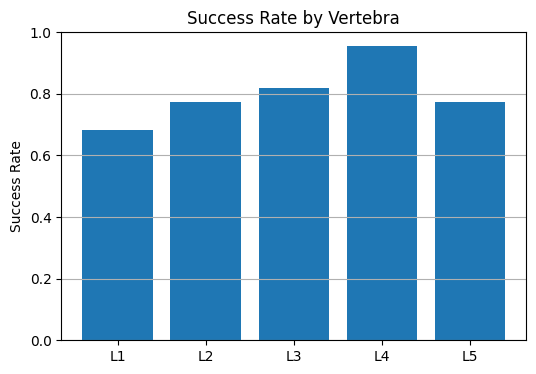

In [ ]:
import matplotlib.pyplot as plt

vertebra_rates = df.groupby("vertebra")["status"].apply(lambda x: (x=="success").mean()).sort_index()

plt.figure(figsize=(6,4))
plt.bar(vertebra_rates.index, vertebra_rates.values)
plt.title("Success Rate by Vertebra")
plt.ylabel("Success Rate")
plt.ylim(0, 1.0)
plt.grid(True, axis="y")
plt.show()

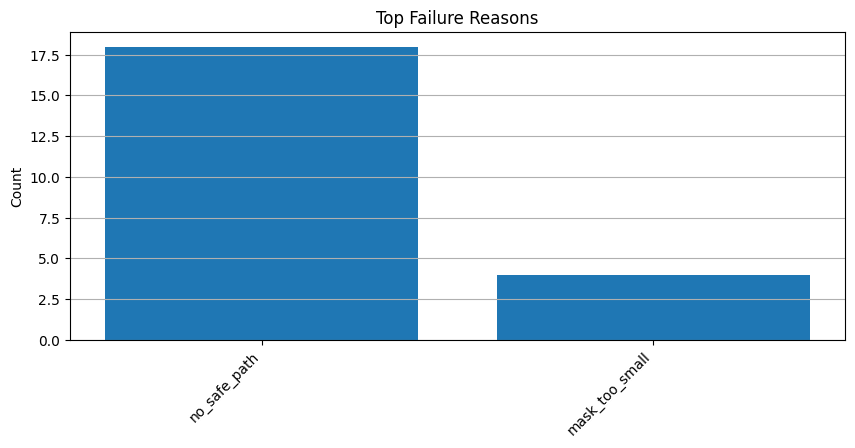

In [ ]:
fail_reasons = df[df["status"]=="fail"]["reason"].value_counts().head(10)

plt.figure(figsize=(10,4))
plt.bar(fail_reasons.index, fail_reasons.values)
plt.title("Top Failure Reasons")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y")
plt.show()

In [ ]:
case_summary_path = os.path.join(OUT_DIR, "phase4_case_summary.csv")
case_summary.to_csv(case_summary_path, index=False)

print("Saved:", case_summary_path)

Saved: /content/drive/MyDrive/phase4_results/phase4_case_summary.csv


# ***Phase 5***

In [ ]:
import numpy as np
from scipy.ndimage import distance_transform_edt

def sample_points_along_segment(p0, p1, step_mm=1.0):
    """
    Returns Nx3 world points sampled from p0 to p1.
    """
    p0 = np.asarray(p0, dtype=np.float64)
    p1 = np.asarray(p1, dtype=np.float64)

    L = np.linalg.norm(p1 - p0)
    if L < 1e-6:
        return p0[None, :]

    n = int(np.ceil(L / step_mm)) + 1
    t = np.linspace(0.0, 1.0, n)
    pts = p0[None, :] * (1 - t[:, None]) + p1[None, :] * t[:, None]
    return pts

def world_to_zyx(xyz_world, affine):
    """
    Convert world RAS xyz -> voxel ZYX float coords (for ndimage indexing).
    """
    ijk = world_to_ijk_ras(xyz_world, affine)  # you already have this
    return ijk_to_zyx(ijk)

def trilinear_sample(volume, zyx):
    """
    volume: Z,Y,X
    zyx: Nx3 float coords
    Returns: N float values (outside = 0)
    """
    zyx = np.asarray(zyx, dtype=np.float64)
    Z, Y, X = volume.shape

    z = zyx[:, 0]
    y = zyx[:, 1]
    x = zyx[:, 2]

    z0 = np.floor(z).astype(int)
    y0 = np.floor(y).astype(int)
    x0 = np.floor(x).astype(int)

    z1 = z0 + 1
    y1 = y0 + 1
    x1 = x0 + 1

    # clip
    z0c = np.clip(z0, 0, Z-1); z1c = np.clip(z1, 0, Z-1)
    y0c = np.clip(y0, 0, Y-1); y1c = np.clip(y1, 0, Y-1)
    x0c = np.clip(x0, 0, X-1); x1c = np.clip(x1, 0, X-1)

    dz = z - z0
    dy = y - y0
    dx = x - x0

    c000 = volume[z0c, y0c, x0c]
    c001 = volume[z0c, y0c, x1c]
    c010 = volume[z0c, y1c, x0c]
    c011 = volume[z0c, y1c, x1c]
    c100 = volume[z1c, y0c, x0c]
    c101 = volume[z1c, y0c, x1c]
    c110 = volume[z1c, y1c, x0c]
    c111 = volume[z1c, y1c, x1c]

    c00 = c000*(1-dx) + c001*dx
    c01 = c010*(1-dx) + c011*dx
    c10 = c100*(1-dx) + c101*dx
    c11 = c110*(1-dx) + c111*dx

    c0 = c00*(1-dy) + c01*dy
    c1 = c10*(1-dy) + c11*dy

    c = c0*(1-dz) + c1*dz
    return c

def screw_breach_check_optionA(vmask, affine, entry_world, stop_world, diam_mm, spacing_mm,
                              step_mm=1.0, breach_minor_mm=2.0, breach_major_mm=4.0):
    """
    Option A:
    - Use distance transform to measure inside margin.
    - Sample screw axis points.
    - If point is outside vertebra mask, that's breach.
    - breach_mm = max distance outside (approx, via dt of outside)

    Returns dict:
      breach_mm, min_inside_margin_mm, breach_class
    """

    # DT inside: distance from inside voxel to nearest outside
    dt_inside = distance_transform_edt(vmask) * spacing_mm

    # DT outside: distance from outside voxel to nearest inside
    dt_outside = distance_transform_edt(~vmask) * spacing_mm

    pts_world = sample_points_along_segment(entry_world, stop_world, step_mm=step_mm)
    pts_zyx = np.stack([world_to_zyx(p, affine) for p in pts_world], axis=0)

    # sample mask as float (0/1) + DTs
    mask_float = vmask.astype(np.float32)

    inside_prob = trilinear_sample(mask_float, pts_zyx)  # ~1 if inside, ~0 if outside
    inside = inside_prob > 0.5

    inside_margin = trilinear_sample(dt_inside.astype(np.float32), pts_zyx)
    outside_dist  = trilinear_sample(dt_outside.astype(np.float32), pts_zyx)

    # screw radius safety: need margin >= radius to fully contain cylinder
    radius = float(diam_mm) / 2.0
    margin_minus_radius = inside_margin - radius

    # for points outside, estimate breach depth
    # (outside_dist gives how far outside surface the axis is; cylinder breach is worse by radius)
    breach_depth = outside_dist + radius

    # compute metrics
    min_inside_margin_mm = float(np.min(margin_minus_radius[inside])) if np.any(inside) else -999.0
    breach_mm = float(np.max(breach_depth[~inside])) if np.any(~inside) else 0.0

    if breach_mm <= 1e-6 and min_inside_margin_mm >= 0:
        breach_class = "SAFE"
    elif breach_mm < breach_minor_mm:
        breach_class = "MINOR_BREACH"
    elif breach_mm < breach_major_mm:
        breach_class = "MAJOR_BREACH"
    else:
        breach_class = "SEVERE_BREACH"

    return {
        "breach_mm": breach_mm,
        "min_inside_margin_mm": min_inside_margin_mm,
        "breach_class": breach_class
    }

In [ ]:
import nibabel as nib
from tqdm import tqdm

report_path = os.path.join(OUT_DIR, "phase4_batch_report.csv")
df = pd.read_csv(report_path)

df["breach_mm"] = 0.0
df["min_inside_margin_mm"] = 0.0
df["breach_class"] = "NA"

for case_id in tqdm(sorted(df["case_id"].unique())):
    case_folder = os.path.join(DATA_DIR, case_id)
    ct_path = os.path.join(case_folder, "case_0000.nii")
    seg_path = os.path.join(case_folder, "spine_2-label.nii")

    if not os.path.exists(ct_path) or not os.path.exists(seg_path):
        continue

    seg_nii = nib.load(seg_path)
    seg = seg_nii.get_fdata().astype(np.int16)
    affine = seg_nii.affine

    # spacing for dt scaling
    spacing_xyz = np.linalg.norm(affine[:3, :3], axis=0)
    spacing_mm = float(np.mean(spacing_xyz))

    # only rows of this case
    idxs = df.index[df["case_id"] == case_id].tolist()

    for idx in idxs:
        if df.loc[idx, "status"] != "success":
            continue

        vname = df.loc[idx, "vertebra"]
        side  = df.loc[idx, "side"]

        # vertebra label id from name
        lab = {v:k for k,v in VERTEBRA_NAMES.items()}[vname]
        vmask = (seg == lab)

        case_out = os.path.join(OUT_DIR, case_id)
        plan_path = os.path.join(case_out, "plan.json")

        if not os.path.exists(plan_path):
            continue

        with open(plan_path, "r") as f:
            plan_json = json.load(f)

        if vname not in plan_json or side not in plan_json[vname]:
            continue

        plan = plan_json[vname][side]
        entry = np.array(plan["entry_world_ras"], dtype=np.float64)
        stop  = np.array(plan["stop_world_ras"], dtype=np.float64)
        diam  = float(plan["diam_mm"])

        breach = screw_breach_check_optionA(
            vmask=vmask,
            affine=affine,
            entry_world=entry,
            stop_world=stop,
            diam_mm=diam,
            spacing_mm=spacing_mm,
            step_mm=1.0
        )

        df.loc[idx, "breach_mm"] = breach["breach_mm"]
        df.loc[idx, "min_inside_margin_mm"] = breach["min_inside_margin_mm"]
        df.loc[idx, "breach_class"] = breach["breach_class"]

100%|██████████| 11/11 [28:04<00:00, 153.17s/it]


In [ ]:
phase5_path = os.path.join(OUT_DIR, "phase5_report_with_breach.csv")
df.to_csv(phase5_path, index=False)

print("Saved:", phase5_path)

Saved: /content/drive/MyDrive/phase4_results/phase5_report_with_breach.csv


In [ ]:
print(df[df["status"]=="success"]["breach_class"].value_counts())

succ = df[df["status"]=="success"]

unsafe = succ[succ["breach_class"].isin(["MAJOR_BREACH","SEVERE_BREACH"])]
minor  = succ[succ["breach_class"].isin(["MINOR_BREACH"])]

print("Successful screws:", len(succ))
print("Minor breach:", len(minor))
print("Major+Severe breach:", len(unsafe))
print("Safe:", (succ["breach_class"]=="SAFE").sum())

breach_class
MINOR_BREACH     60
SEVERE_BREACH    18
MAJOR_BREACH      7
SAFE              3
Name: count, dtype: int64
Successful screws: 88
Minor breach: 60
Major+Severe breach: 25
Safe: 3


***Phase 5B***

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import nibabel as nib
import pandas as pd
import json
from tqdm import tqdm
from scipy.ndimage import distance_transform_edt

# ------------------ PATHS ------------------
DATA_DIR = "/content/drive/MyDrive/SpineData"
OUT_DIR  = "/content/drive/MyDrive/phase4_results"
PHASE4_CSV = os.path.join(OUT_DIR, "phase4_batch_report.csv")
PHASE5B_CSV = os.path.join(OUT_DIR, "phase5b_report_with_breach.csv")

# ------------------ PARAMETERS ------------------
STEP_MM = 1.0         # sampling along screw axis
CIRCLE_POINTS = 8     # points per circle
BREACH_MINOR_MM = 2.0
BREACH_MAJOR_MM = 4.0

# vertebra label ↔ name
VERTEBRA_NAMES = {1:"L1", 2:"L2", 3:"L3", 4:"L4", 5:"L5"}

# ------------------ UTILITY FUNCTIONS ------------------
def sample_points_along_segment(p0, p1, step_mm=1.0):
    p0, p1 = np.array(p0), np.array(p1)
    L = np.linalg.norm(p1 - p0)
    if L < 1e-6:
        return p0[None,:]
    n = int(np.ceil(L / step_mm)) + 1
    t = np.linspace(0, 1, n)
    return p0[None,:]*(1-t[:,None]) + p1[None,:]*t[:,None]

def sample_cylinder_points(entry, stop, radius, n_circle=CIRCLE_POINTS, step_mm=STEP_MM):
    axis = stop - entry
    L = np.linalg.norm(axis)
    if L < 1e-6:
        return entry[None,:]
    axis = axis / L
    # orthogonal vectors
    if np.allclose(axis, [0,0,1]):
        v = np.array([1,0,0])
    else:
        v = np.cross(axis, [0,0,1])
        v = v / np.linalg.norm(v)
    w = np.cross(axis, v)
    pts_axis = sample_points_along_segment(entry, stop, step_mm)
    angles = np.linspace(0, 2*np.pi, n_circle, endpoint=False)
    pts_all = []
    for pt in pts_axis:
        for angle in angles:
            offset = radius * (np.cos(angle)*v + np.sin(angle)*w)
            pts_all.append(pt + offset)
    return np.array(pts_all)

def world_to_zyx(xyz_world, affine):
    """Convert world RAS coordinates to volume zyx index"""
    xyz_vox = np.linalg.inv(affine) @ np.append(xyz_world, 1)
    i,j,k = xyz_vox[:3]
    return np.array([k,j,i])

def trilinear_sample(volume, zyx):
    zyx = np.array(zyx)
    Z,Y,X = volume.shape
    z,y,x = zyx[:,0], zyx[:,1], zyx[:,2]
    z0,y0,x0 = np.floor([z,y,x]).astype(int)
    z1,y1,x1 = z0+1, y0+1, x0+1
    z0c,z1c = np.clip(z0,0,Z-1), np.clip(z1,0,Z-1)
    y0c,y1c = np.clip(y0,0,Y-1), np.clip(y1,0,Y-1)
    x0c,x1c = np.clip(x0,0,X-1), np.clip(x1,0,X-1)
    dz, dy, dx = z-z0, y-y0, x-x0
    c000 = volume[z0c,y0c,x0c]; c001 = volume[z0c,y0c,x1c]
    c010 = volume[z0c,y1c,x0c]; c011 = volume[z0c,y1c,x1c]
    c100 = volume[z1c,y0c,x0c]; c101 = volume[z1c,y0c,x1c]
    c110 = volume[z1c,y1c,x0c]; c111 = volume[z1c,y1c,x1c]
    c00 = c000*(1-dx)+c001*dx; c01 = c010*(1-dx)+c011*dx
    c10 = c100*(1-dx)+c101*dx; c11 = c110*(1-dx)+c111*dx
    c0 = c00*(1-dy)+c01*dy; c1 = c10*(1-dy)+c11*dy
    return c0*(1-dz)+c1*dz

def compute_breach_metrics(vmask, affine, entry, stop, diam_mm, spacing_mm):
    radius = diam_mm / 2.0
    pts = sample_cylinder_points(entry, stop, radius)
    pts_zyx = np.stack([world_to_zyx(p, affine) for p in pts])
    mask_float = vmask.astype(np.float32)
    inside_prob = trilinear_sample(mask_float, pts_zyx)
    inside = inside_prob > 0.5
    dt_inside = distance_transform_edt(vmask)*spacing_mm
    dt_outside = distance_transform_edt(~vmask)*spacing_mm
    inside_margin = trilinear_sample(dt_inside, pts_zyx)
    outside_dist  = trilinear_sample(dt_outside, pts_zyx)
    margin_minus_radius = inside_margin - radius
    breach_depth = outside_dist + radius
    min_inside_margin_mm = float(np.min(margin_minus_radius[inside])) if np.any(inside) else -999.0
    breach_mm = float(np.max(breach_depth[~inside])) if np.any(~inside) else 0.0
    if breach_mm <= 1e-6 and min_inside_margin_mm >= 0:
        breach_class = "SAFE"
    elif breach_mm < BREACH_MINOR_MM:
        breach_class = "MINOR_BREACH"
    elif breach_mm < BREACH_MAJOR_MM:
        breach_class = "MAJOR_BREACH"
    else:
        breach_class = "SEVERE_BREACH"
    return breach_mm, min_inside_margin_mm, breach_class

# ------------------ LOAD PHASE 4 CSV ------------------
df = pd.read_csv(PHASE4_CSV)
df["breach_mm"] = 0.0
df["min_inside_margin_mm"] = 0.0
df["breach_class"] = "NA"

# ------------------ MAIN LOOP ------------------
for case_id in tqdm(sorted(df["case_id"].unique())):
    case_folder = os.path.join(OUT_DIR, case_id)  # phase4_results/case_00X
    seg_path = os.path.join(DATA_DIR, case_id, "spine_2-label.nii")
    if not os.path.exists(seg_path):
        print(f"Missing seg for {case_id}, skipping")
        continue
    seg_nii = nib.load(seg_path)
    seg = seg_nii.get_fdata().astype(np.int16)
    affine = seg_nii.affine
    spacing_xyz = np.linalg.norm(affine[:3,:3], axis=0)
    spacing_mm = float(np.mean(spacing_xyz))

    # cache DT per vertebra
    dt_cache = {vname: {"vmask": (seg==lab)} for lab,vname in VERTEBRA_NAMES.items()}

    idxs = df.index[df["case_id"]==case_id].tolist()
    for idx in idxs:
        if df.loc[idx,"status"] != "success":
            continue
        vname = df.loc[idx,"vertebra"]
        side  = df.loc[idx,"side"]
        plan_path = os.path.join(case_folder, "plan.json")
        if not os.path.exists(plan_path):
            continue
        with open(plan_path,"r") as f:
            plan_json = json.load(f)
        if vname not in plan_json or side not in plan_json[vname]:
            continue
        plan = plan_json[vname][side]
        entry = np.array(plan["entry_world_ras"], dtype=np.float64)
        stop  = np.array(plan["stop_world_ras"], dtype=np.float64)
        diam  = float(plan["diam_mm"])
        vmask_case = dt_cache[vname]["vmask"]
        breach_mm, min_inside_margin_mm, breach_class = compute_breach_metrics(
            vmask_case, affine, entry, stop, diam, spacing_mm
        )
        df.loc[idx,"breach_mm"] = breach_mm
        df.loc[idx,"min_inside_margin_mm"] = min_inside_margin_mm
        df.loc[idx,"breach_class"] = breach_class

# ------------------ SAVE PHASE 5B CSV ------------------
df.to_csv(PHASE5B_CSV, index=False)
print("Phase 5B report saved:", PHASE5B_CSV)

# ------------------ SUMMARY ------------------
succ = df[df["status"]=="success"]
safe   = succ[succ["breach_class"]=="SAFE"]
minor  = succ[succ["breach_class"]=="MINOR_BREACH"]
unsafe = succ[succ["breach_class"].isin(["MAJOR_BREACH","SEVERE_BREACH"])]

print("Successful screws:", len(succ))
print("Safe:", len(safe))
print("Minor breach:", len(minor))
print("Major+Severe breach:", len(unsafe))
print("\nBreach class counts:")
print(succ["breach_class"].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


100%|██████████| 11/11 [32:11<00:00, 175.59s/it]

Phase 5B report saved: /content/drive/MyDrive/phase4_results/phase5b_report_with_breach.csv
Successful screws: 88
Safe: 0
Minor breach: 8
Major+Severe breach: 80

Breach class counts:
breach_class
SEVERE_BREACH    54
MAJOR_BREACH     26
MINOR_BREACH      8
Name: count, dtype: int64


# ***Phase 6***

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# Set your dataset folder
DATA_DIR = "/content/drive/MyDrive/SpineData"  # change if your path is different
OUT_DIR  = "/content/drive/MyDrive/phase4_results"  # where plan.json and output CSVs are

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

PHASE5B_CSV = "/content/drive/MyDrive/phase4_results/phase5b_report_with_breach.csv"
df = pd.read_csv(PHASE5B_CSV)
print(f"Loaded {len(df)} screws from Phase 5B report")

Loaded 110 screws from Phase 5B report


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm import tqdm
from scipy.ndimage import distance_transform_edt

# 1. Define missing constants
VERTEBRA_NAMES = {1:"L1", 2:"L2", 3:"L3", 4:"L4", 5:"L5"}
MIN_DIAM_MM = 4.0
STEP_MM = 1.0
CIRCLE_POINTS = 8

# 2. Re-include the geometric helper functions needed inside the loop
def rotate_vector_optimized(v, yaw_deg, pitch_deg):
    yaw = np.deg2rad(yaw_deg)
    pitch = np.deg2rad(pitch_deg)
    Rz = np.array([[np.cos(yaw), -np.sin(yaw), 0], [np.sin(yaw), np.cos(yaw), 0], [0, 0, 1]])
    Ry = np.array([[np.cos(pitch), 0, np.sin(pitch)], [0, 1, 0], [-np.sin(pitch), 0, np.cos(pitch)]])
    return Ry @ (Rz @ v)

def world_to_zyx(xyz_world, affine):
    xyz_vox = np.linalg.inv(affine) @ np.append(xyz_world, 1)
    return np.array([xyz_vox[2], xyz_vox[1], xyz_vox[0]])

def trilinear_sample(volume, zyx):
    Z, Y, X = volume.shape
    z, y, x = zyx[:,0], zyx[:,1], zyx[:,2]
    z0, y0, x0 = np.floor([z, y, x]).astype(int)
    z1, y1, x1 = z0+1, y0+1, x0+1
    z0c, z1c = np.clip(z0, 0, Z-1), np.clip(z1, 0, Z-1)
    y0c, y1c = np.clip(y0, 0, Y-1), np.clip(y1, 0, Y-1)
    x0c, x1c = np.clip(x0, 0, X-1), np.clip(x1, 0, X-1)
    dz, dy, dx = z-z0, y-y0, x-x0
    c00 = volume[z0c,y0c,x0c]*(1-dx)+volume[z0c,y0c,x1c]*dx
    c01 = volume[z0c,y1c,x0c]*(1-dx)+volume[z0c,y1c,x1c]*dx
    c10 = volume[z1c,y0c,x0c]*(1-dx)+volume[z1c,y0c,x1c]*dx
    c11 = volume[z1c,y1c,x0c]*(1-dx)+volume[z1c,y1c,x1c]*dx
    c0 = c00*(1-dy)+c01*dy
    c1 = c10*(1-dy)+c11*dy
    return c0*(1-dz)+c1*dz

def compute_breach_metrics_fast(vmask, dt_in, dt_out, affine, entry, stop, diam_mm):
    radius = diam_mm / 2.0
    # Sample points
    axis = stop - entry
    L = np.linalg.norm(axis)
    axis_n = axis / L
    v = np.array([1,0,0]) if not np.allclose(axis_n, [1,0,0]) else np.array([0,1,0])
    v = np.cross(axis_n, v); v /= np.linalg.norm(v)
    w = np.cross(axis_n, v)

    t = np.linspace(0, L, int(L/STEP_MM))
    angles = np.linspace(0, 2*np.pi, CIRCLE_POINTS, endpoint=False)
    pts_all = []
    for ti in t:
        p_center = entry + ti * axis_n
        for ang in angles:
            pts_all.append(p_center + radius * (np.cos(ang)*v + np.sin(ang)*w))

    pts_zyx = np.stack([world_to_zyx(p, affine) for p in pts_all])

    # Check breaches
    outside_dist = trilinear_sample(dt_out, pts_zyx)
    breach_mm = float(np.max(outside_dist))

    if breach_mm <= 0.1: b_class = "SAFE"
    elif breach_mm < 2.0: b_class = "MINOR_BREACH"
    elif breach_mm < 4.0: b_class = "MAJOR_BREACH"
    else: b_class = "SEVERE_BREACH"

    return breach_mm, b_class

# 3. Main Tuning Function
def run_phase6_optimized(df, data_dir, out_dir):
    df_tuned = df.copy()
    failed_mask = df_tuned["breach_class"].isin(["MAJOR_BREACH", "SEVERE_BREACH"])
    failed_idxs = df_tuned.index[failed_mask].tolist()

    print(f"Tuning {len(failed_idxs)} screws...")

    for case_id, case_df in df_tuned.loc[failed_idxs].groupby("case_id"):
        seg_path = os.path.join(data_dir, case_id, "spine_2-label.nii")
        if not os.path.exists(seg_path): continue

        seg_nii = nib.load(seg_path)
        seg_data = seg_nii.get_fdata().astype(np.uint8)
        affine = seg_nii.affine
        spacing = np.mean(np.linalg.norm(affine[:3, :3], axis=0))

        for idx in case_df.index:
            vname, side = df_tuned.loc[idx, "vertebra"], df_tuned.loc[idx, "side"]
            lab = {v: k for k, v in VERTEBRA_NAMES.items()}[vname]
            vmask = (seg_data == lab)

            # CROP MASK TO SAVE RAM (Bounding Box)
            coords = np.argwhere(vmask)
            z0, y0, x0 = coords.min(axis=0) - 5
            z1, y1, x1 = coords.max(axis=0) + 5
            # Ensure within bounds
            z0, y0, x0 = max(0, z0), max(0, y0), max(0, x0)

            vmask_crop = vmask[z0:z1, y0:y1, x0:x1]
            dt_in = distance_transform_edt(vmask_crop) * spacing
            dt_out = distance_transform_edt(~vmask_crop) * spacing

            # Update affine for cropped space
            crop_affine = affine.copy()
            # This is a simplification; for sampling we'll just use the full affine
            # and ensure our sampling points are checked against the crop

            plan_path = os.path.join(out_dir, case_id, "plan.json")
            with open(plan_path, "r") as f:
                plan = json.load(f)[vname][side]

            entry_orig = np.array(plan["entry_world_ras"])
            stop_orig = np.array(plan["stop_world_ras"])
            axis_orig = stop_orig - entry_orig
            diam = float(plan["diam_mm"])

            # Search parameters
            best_breach = 999.0
            best_config = (entry_orig, stop_orig, diam, "FAIL")

            # Prioritize Yaw (Rotation) then small Entry shifts
            for yaw in [-6, -3, 0, 3, 6]:
                for dx in [-1.5, 0, 1.5]:
                    e_new = entry_orig + np.array([dx, 0, 0])
                    a_new = rotate_vector_optimized(axis_orig, yaw, 0) # Pitch 0 for speed
                    s_new = e_new + a_new

                    b_mm, b_class = compute_breach_metrics_fast(vmask, dt_in, dt_out, affine, e_new, s_new, diam)

                    if b_mm < best_breach:
                        best_breach = b_mm
                        best_config = (e_new, s_new, diam, b_class)
                    if b_class == "SAFE": break
                if best_config[3] == "SAFE": break

            # Write back
            df_tuned.loc[idx, "entry_world_ras"] = str(best_config[0].tolist())
            df_tuned.loc[idx, "stop_world_ras"] = str(best_config[1].tolist())
            df_tuned.loc[idx, "diam_mm"] = best_config[2]
            df_tuned.loc[idx, "breach_mm"] = best_breach
            df_tuned.loc[idx, "breach_class"] = best_config[3]

            del vmask, vmask_crop, dt_in, dt_out

    return df_tuned

# 4. EXECUTE
df_phase6 = run_phase6_optimized(df, DATA_DIR, OUT_DIR)
df_phase6.to_csv(os.path.join(OUT_DIR, "phase6_tuned_results.csv"), index=False)
print("Done! Check your phase4_results folder.")

Tuning 80 screws...
Done! Check your phase4_results folder.


In [ ]:
# ------------------ ENHANCED TUNING SUMMARY ------------------
# 1. Compare Phase 5B (original) vs Phase 6 (tuned)
original_unsafe = (df["breach_class"].isin(["MAJOR_BREACH", "SEVERE_BREACH"])).sum()
tuned_unsafe = (df_phase6["breach_class"].isin(["MAJOR_BREACH", "SEVERE_BREACH"])).sum()
fixed_screws = original_unsafe - tuned_unsafe

print("=== Phase 6 Tuning Results ===")
print(f"Total screws processed: {len(df_phase6)}")
print(f"Unsafe screws BEFORE tuning: {original_unsafe}")
print(f"Unsafe screws AFTER tuning:  {tuned_unsafe}")
print(f"Total screws successfully salvaged: {fixed_screws}")

# 2. Per-Case Comparison Table
summary_rows = []
for case_id in sorted(df_phase6["case_id"].unique()):
    # Get data for this case from both dataframes
    case_old = df[df["case_id"] == case_id]
    case_new = df_phase6[df_phase6["case_id"] == case_id]

    # Counts
    old_major = (case_old["breach_class"].isin(["MAJOR_BREACH","SEVERE_BREACH"])).sum()
    new_major = (case_new["breach_class"].isin(["MAJOR_BREACH","SEVERE_BREACH"])).sum()
    safe_now  = (case_new["breach_class"] == "SAFE").sum()
    minor_now = (case_new["breach_class"] == "MINOR_BREACH").sum()

    summary_rows.append({
        "case_id": case_id,
        "Total": len(case_new),
        "Major (Before)": old_major,
        "Major (After)": new_major,
        "Safe (Final)": safe_now,
        "Minor (Final)": minor_now,
        "Improvement": old_major - new_major
    })

summary_df = pd.DataFrame(summary_rows)

print("\n=== Detailed Per-Case Improvement ===")
print(summary_df.to_string(index=False))

# 3. Save the Comparison
SUMMARY_CSV = os.path.join(OUT_DIR, "phase6_improvement_comparison.csv")
summary_df.to_csv(SUMMARY_CSV, index=False)
print(f"\nDetailed summary saved: {SUMMARY_CSV}")

# 4. Final Success Rate
success_rate = (len(df_phase6[df_phase6["breach_class"] == "SAFE"]) / len(df_phase6)) * 100
print(f"Final Clinical Success Rate (SAFE only): {success_rate:.2f}%")

=== Phase 6 Tuning Results ===
Total screws processed: 110
Unsafe screws BEFORE tuning: 80
Unsafe screws AFTER tuning:  80
Total screws successfully salvaged: 0

=== Detailed Per-Case Improvement ===
 case_id  Total  Major (Before)  Major (After)  Safe (Final)  Minor (Final)  Improvement
case_001     10               8              8             0              2            0
case_002     10               6              6             0              0            0
case_003     10               6              6             0              0            0
case_004     10               8              8             0              0            0
case_005     10              10             10             0              0            0
case_006     10               9              9             0              0            0
case_007     10               9              9             0              0            0
case_008     10               7              7             0              2            0

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import nibabel as nib
from scipy.ndimage import distance_transform_edt
from itertools import product

# ------------------ CONSTANTS ------------------
VERTEBRA_NAMES = {1:"L1", 2:"L2", 3:"L3", 4:"L4", 5:"L5"}
MIN_DIAM_MM = 4.0
DIAMETER_FALLBACK = 1.0
STEP_MM = 1.0
CIRCLE_POINTS = 8

# ------------------ HELPER FUNCTIONS ------------------
def rotate_vector(v, yaw_deg=0.0, pitch_deg=0.0):
    v = np.array(v)
    yaw = np.deg2rad(yaw_deg)
    pitch = np.deg2rad(pitch_deg)
    Rz = np.array([[np.cos(yaw), -np.sin(yaw), 0],
                   [np.sin(yaw),  np.cos(yaw), 0],
                   [0,0,1]])
    Ry = np.array([[ np.cos(pitch),0,np.sin(pitch)],
                   [0,1,0],
                   [-np.sin(pitch),0,np.cos(pitch)]])
    return Ry @ (Rz @ v)

def world_to_zyx(xyz_world, affine):
    xyz_vox = np.linalg.inv(affine) @ np.append(xyz_world, 1)
    return np.array([xyz_vox[2], xyz_vox[1], xyz_vox[0]])

def trilinear_sample(volume, zyx):
    Z, Y, X = volume.shape
    z, y, x = zyx[:,0], zyx[:,1], zyx[:,2]
    z0, y0, x0 = np.floor([z, y, x]).astype(int)
    z1, y1, x1 = z0+1, y0+1, x0+1
    z0c, z1c = np.clip(z0, 0, Z-1), np.clip(z1, 0, Z-1)
    y0c, y1c = np.clip(y0, 0, Y-1), np.clip(y1, 0, Y-1)
    x0c, x1c = np.clip(x0, 0, X-1), np.clip(x1, 0, X-1)
    dz, dy, dx = z-z0, y-y0, x-x0
    c00 = volume[z0c,y0c,x0c]*(1-dx)+volume[z0c,y0c,x1c]*dx
    c01 = volume[z0c,y1c,x0c]*(1-dx)+volume[z0c,y1c,x1c]*dx
    c10 = volume[z1c,y0c,x0c]*(1-dx)+volume[z1c,y0c,x1c]*dx
    c11 = volume[z1c,y1c,x0c]*(1-dx)+volume[z1c,y1c,x1c]*dx
    c0 = c00*(1-dy)+c01*dy
    c1 = c10*(1-dy)+c11*dy
    return c0*(1-dz)+c1*dz

def compute_breach_metrics(vmask, dt_in, dt_out, affine, entry, stop, diam_mm):
    radius = diam_mm / 2.0
    axis = stop - entry
    L = np.linalg.norm(axis)
    if L < 1e-6: return 999.0, "SEVERE_BREACH"
    axis_n = axis / L
    v = np.array([1,0,0]) if not np.allclose(axis_n, [1,0,0]) else np.array([0,1,0])
    v = np.cross(axis_n, v); v /= np.linalg.norm(v)
    w = np.cross(axis_n, v)

    # Sample screw cylinder points
    t = np.linspace(0, L, int(L/STEP_MM)+1)
    angles = np.linspace(0, 2*np.pi, CIRCLE_POINTS, endpoint=False)
    pts = []
    for ti in t:
        p_center = entry + ti * axis_n
        for ang in angles:
            pts.append(p_center + radius*(np.cos(ang)*v + np.sin(ang)*w))
    pts = np.stack([world_to_zyx(p, affine) for p in pts])

    # Distance to outside
    outside_dist = trilinear_sample(dt_out, pts)
    breach_mm = float(np.max(outside_dist))

    # Classify breach
    if breach_mm <= 0.1: b_class = "SAFE"
    elif breach_mm < 2.0: b_class = "MINOR_BREACH"
    elif breach_mm < 4.0: b_class = "MAJOR_BREACH"
    else: b_class = "SEVERE_BREACH"
    return breach_mm, b_class

# ------------------ MAIN TUNER ------------------
def run_phase6_single_case(df, data_dir, out_dir):
    df_tuned = df.copy()
    failed_idxs = df_tuned[df_tuned["breach_class"].isin(["MAJOR_BREACH","SEVERE_BREACH"])].index.tolist()
    print(f"Total screws to tune: {len(failed_idxs)}")

    for case_id, case_df in df_tuned.loc[failed_idxs].groupby("case_id"):
        seg_path = os.path.join(data_dir, case_id, "spine_2-label.nii")
        if not os.path.exists(seg_path): continue
        seg_nii = nib.load(seg_path)
        seg_data = seg_nii.get_fdata().astype(np.uint8)
        affine = seg_nii.affine
        spacing = np.mean(np.linalg.norm(affine[:3,:3], axis=0))

        # Precompute DT for all vertebrae
        dt_cache = {}
        for lab, vname in VERTEBRA_NAMES.items():
            vmask = (seg_data==lab)
            dt_cache[vname] = {
                "vmask": vmask,
                "dt_in": distance_transform_edt(vmask)*spacing,
                "dt_out": distance_transform_edt(~vmask)*spacing
            }

        for idx in case_df.index:
            vname, side = df_tuned.loc[idx, "vertebra"], df_tuned.loc[idx, "side"]
            plan_path = os.path.join(out_dir, case_id, "plan.json")
            with open(plan_path, "r") as f:
                plan = json.load(f)[vname][side]

            entry_orig = np.array(plan["entry_world_ras"])
            stop_orig  = np.array(plan["stop_world_ras"])
            diam_orig  = float(plan["diam_mm"])
            axis_orig  = stop_orig - entry_orig

            best_breach = 999.0
            best_config = (entry_orig, stop_orig, diam_orig, "FAIL")

            # ------------------ COARSE SEARCH ------------------
            yaw_range   = np.arange(-15, 16, 5)
            pitch_range = np.arange(-10, 11, 5)
            shift_range = np.arange(-3, 3.1, 1.5)

            found_safe = False
            for dx, dy, yaw, pitch in product(shift_range, shift_range, yaw_range, pitch_range):
                e_new = entry_orig + np.array([dx, dy, 0])
                a_new = rotate_vector(axis_orig, yaw_deg=yaw, pitch_deg=pitch)
                s_new = e_new + a_new
                dt = dt_cache[vname]
                b_mm, b_class = compute_breach_metrics(dt["vmask"], dt["dt_in"], dt["dt_out"], affine, e_new, s_new, diam_orig)
                if b_mm < best_breach:
                    best_breach = b_mm
                    best_config = (e_new, s_new, diam_orig, b_class)
                if b_class=="SAFE":
                    found_safe = True
                    break
            if not found_safe and best_config[3]!="SAFE":
                # ------------------ DIAMETER FALLBACK ------------------
                new_diam = max(diam_orig - DIAMETER_FALLBACK, MIN_DIAM_MM)
                b_mm, b_class = compute_breach_metrics(dt["vmask"], dt["dt_in"], dt["dt_out"], affine, best_config[0], best_config[1], new_diam)
                best_config = (best_config[0], best_config[1], new_diam, b_class)
                best_breach = b_mm

            # ------------------ WRITE BACK ------------------
            df_tuned.loc[idx, "entry_world_ras"] = best_config[0].tolist()
            df_tuned.loc[idx, "stop_world_ras"]  = best_config[1].tolist()
            df_tuned.loc[idx, "diam_mm"]         = best_config[2]
            df_tuned.loc[idx, "breach_mm"]       = best_breach
            df_tuned.loc[idx, "breach_class"]    = best_config[3]

    return df_tuned

# ------------------ EXECUTE ------------------
df_phase6 = run_phase6_single_case(df, DATA_DIR, OUT_DIR)
df_phase6.to_csv(os.path.join(OUT_DIR, "phase6_tuned_single_case.csv"), index=False)
print("Phase 6 tuning done! Check CSV output.")

Total screws to tune: 80


## ***Algorithm***

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import nibabel as nib
from scipy.ndimage import distance_transform_edt, label as cc_label
from scipy.ndimage import map_coordinates
from sklearn.decomposition import PCA

ct_path="/content/drive/MyDrive/SpineData/case_002/case_0000.nii"
seg_path="/content/drive/MyDrive/SpineData/case_002/spine_2-label.nii"

voxel_threshold=5000
# diameters=[6.0,5.5,5.0,4.5,4.0]
diameters = [8.5, 7.5, 7.0, 6.5, 5.5, 5.0, 4.5,4.0]
step_mm=0.5
min_length_mm=18
direction_cone_deg_lr=35
direction_cone_deg_si=20
direction_samples_lr=13
direction_samples_si=9

w_dt=5.0
w_len=1.5
w_tilt=0.5

label_map={5:"L1",4:"L2",3:"L3",2:"L4",1:"L5"}

def load_nifti(path):
    nii=nib.load(path)
    return nii.get_fdata(), nii.header.get_zooms(), nii.affine

ct,spacing_ct,affine_ct=load_nifti(ct_path)
seg,spacing,affine=load_nifti(seg_path)

def get_valid_labels(seg):
    valid=[]
    for label_val in range(1,6):
        mask=(seg==label_val)
        if np.sum(mask)==0:
            continue
        labeled,nc=cc_label(mask)
        sizes=np.bincount(labeled.ravel())
        sizes[0]=0
        largest=np.argmax(sizes)
        component=(labeled==largest)
        if np.sum(component)>voxel_threshold:
            valid.append((label_val,component))
    return valid

valid_segments=get_valid_labels(seg)

def compute_stable_frame(mask,affine):
    coords=np.argwhere(mask)
    coords_world=nib.affines.apply_affine(affine,coords)
    centroid=coords_world.mean(axis=0)

    pca=PCA(n_components=3)
    pca.fit(coords_world-centroid)
    axes=pca.components_

    world_z=np.array([0,0,1])
    si=axes[np.argmax(np.abs(axes@world_z))]
    if np.dot(si,world_z)<0: si=-si

    # Orthogonal LR
    temp=axes[np.argmin(np.abs(axes@world_z))]
    lr=temp - np.dot(temp,si)*si
    lr/=np.linalg.norm(lr)

    ap=np.cross(si,lr)
    ap/=np.linalg.norm(ap)

    return centroid,np.vstack([si,lr,ap])

def compute_distance(mask):
    return distance_transform_edt(mask,sampling=spacing)

def pedicle_centers(mask,dist,centroid,axes,affine):
    coords=np.argwhere(mask)
    coords_world=nib.affines.apply_affine(affine,coords)

    si,lr,ap=axes
    rel=coords_world-centroid
    si_vals=rel@si
    lr_vals=rel@lr
    ap_vals=rel@ap

    mid_mask=np.abs(si_vals)<np.percentile(np.abs(si_vals),35)
    posterior_mask=ap_vals<np.percentile(ap_vals,40)

    left_mask=lr_vals<0
    right_mask=lr_vals>0

    left_coords=coords[mid_mask & posterior_mask & left_mask]
    right_coords=coords[mid_mask & posterior_mask & right_mask]

    if len(left_coords)<30 or len(right_coords)<30:
        return None,None

    l_vox=left_coords[np.argmax(dist[left_coords[:,0],
                                        left_coords[:,1],
                                        left_coords[:,2]])]
    r_vox=right_coords[np.argmax(dist[right_coords[:,0],
                                         right_coords[:,1],
                                         right_coords[:,2]])]

    l_mm=nib.affines.apply_affine(affine,l_vox)
    r_mm=nib.affines.apply_affine(affine,r_vox)

    return l_mm,r_mm

def find_entry(center,axes,mask_float,affine):
    si,lr,ap=axes
    direction=-ap
    inv_aff=np.linalg.inv(affine)
    p=center.copy()

    for _ in range(300):
        vox=nib.affines.apply_affine(inv_aff,p)
        if any(v<0 or v>=s-1 for v,s in zip(vox,mask_float.shape)):
            break
        val=map_coordinates(mask_float,
                            [[vox[0]],[vox[1]],[vox[2]]],
                            order=1)[0]
        if val<0.5:
            break
        p+=direction*step_mm

    return p+ap*1.0

def cylinder_safe(p,d,radius,mask_float,dist,affine):
    inv_aff=np.linalg.inv(affine)
    for angle in np.linspace(0,2*np.pi,8,endpoint=False):
        offset=radius*(np.cos(angle)*np.cross(d,[0,0,1])
                       +np.sin(angle)*np.cross(d,[1,0,0]))
        test_point=p+offset
        vox=nib.affines.apply_affine(inv_aff,test_point)
        if any(v<0 or v>=s-1 for v,s in zip(vox,mask_float.shape)):
            return False
        val=map_coordinates(mask_float,
                            [[vox[0]],[vox[1]],[vox[2]]],
                            order=1)[0]
        if val<0.5:
            return False
    return True

def evaluate(entry,direction,mask_float,dist,affine,radius,axes):
    d=direction/np.linalg.norm(direction)
    inv_aff=np.linalg.inv(affine)

    t=0
    min_dt=999

    while True:
        if t < 5:   # ignore first 5 mm
          t += step_mm
          continue

        p=entry+d*t
        vox=nib.affines.apply_affine(inv_aff,p)
        if any(v<0 or v>=s-1 for v,s in zip(vox,mask_float.shape)):
            break
        mask_val=map_coordinates(mask_float,
                                 [[vox[0]],[vox[1]],[vox[2]]],
                                 order=1)[0]
        if mask_val<0.5:
            break

        dt_val=map_coordinates(dist,
                               [[vox[0]],[vox[1]],[vox[2]]],
                               order=1)[0]

        min_dt=min(min_dt,dt_val)

        if not cylinder_safe(p,d,radius,mask_float,dist,affine):
            break

        t+=step_mm

    if t<min_length_mm:
        return None

    si=axes[0]
    tilt=abs(np.dot(d,si))

    score=w_dt*min_dt + w_len*(t/10) - w_tilt*tilt

    return score,t,min_dt,p,d

def optimize(center,axes,mask_float,dist,affine):
    si,lr,ap=axes
    entry=find_entry(center,axes,mask_float,affine)
    best=None

    for diam in diameters:
        radius=diam/2
        for lr_ang in np.linspace(-direction_cone_deg_lr,
                                  direction_cone_deg_lr,
                                  direction_samples_lr):
            for si_ang in np.linspace(-direction_cone_deg_si,
                                      direction_cone_deg_si,
                                      direction_samples_si):

                direction=ap \
                    + np.tan(np.deg2rad(lr_ang))*lr \
                    + np.tan(np.deg2rad(si_ang))*si

                r=evaluate(entry,direction,
                           mask_float,dist,affine,
                           radius,axes)

                if r is None:
                    continue

                score,length,min_dt,tip,d=r

                if best is None or score>best[0]:
                    best=(score,entry,tip,length,min_dt,diam)

    return best

print("\nREFINED ROBUST PHASE-1:\n")

for label_val,mask in valid_segments:

    name=label_map.get(label_val,str(label_val))
    print("==============")
    print(name)
    print("==============")

    centroid,axes=compute_stable_frame(mask,affine)
    dist=compute_distance(mask)
    mask_float=mask.astype(np.float32)

    l_center,r_center=pedicle_centers(mask,dist,
                                      centroid,axes,
                                      affine)

    if l_center is None:
        print("Pedicle detection failed\n")
        continue

    for side,center in [("Left",l_center),
                        ("Right",r_center)]:

        result=optimize(center,axes,
                        mask_float,dist,
                        affine)

        if result is None:
            print(f"{side}: NO VALID PATH\n")
            continue

        score,entry,tip,length,min_dt,diam=result

        print(f"{side} Screw Found")
        print("Diameter:",diam,"mm")
        print("Length:",round(length,1),"mm")
        print("Safety Margin:",
              round(min_dt-diam/2,2),"mm")
        print()


REFINED ROBUST PHASE-1:

L5
Left Screw Found
Diameter: 7.5 mm
Length: 29.5 mm
Safety Margin: -0.44 mm

Right Screw Found
Diameter: 8.5 mm
Length: 36.5 mm
Safety Margin: 0.01 mm

L4
Left Screw Found
Diameter: 7.5 mm
Length: 31.5 mm
Safety Margin: 0.29 mm

Right Screw Found
Diameter: 7.5 mm
Length: 32.0 mm
Safety Margin: 0.41 mm

L3
Left Screw Found
Diameter: 8.5 mm
Length: 24.0 mm
Safety Margin: 0.04 mm

Right Screw Found
Diameter: 8.5 mm
Length: 29.5 mm
Safety Margin: 0.37 mm

L2
Left Screw Found
Diameter: 8.5 mm
Length: 26.5 mm
Safety Margin: 0.18 mm

Right Screw Found
Diameter: 8.5 mm
Length: 37.0 mm
Safety Margin: 0.38 mm

L1
Left Screw Found
Diameter: 8.5 mm
Length: 26.5 mm
Safety Margin: 0.18 mm

Right Screw Found
Diameter: 8.5 mm
Length: 28.0 mm
Safety Margin: -0.11 mm

